# Action potential waveforms are state-dependent
### 5. AP waveform predicts peri-spike LFP state

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

The local field potential (LFP) reflects the summed activity of the network surrounding a neuron. There is a long standing view that the LFP is a byproduct of spiking, a kind of neuronal "exhaust". Here we ask the reverse question: does the shape of a single neuron's action potential carry information about the network state it is embedded in, beyond what its firing rate alone tells us?

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys
sys.path.append('finding_notebooks_functions/')
from finding5_functions import (plot_example_recording, load_ridge_population,
                                run_population_stats, print_fraction_significant, plot_r2_boxplot,
                                plot_all_lfp_features, plot_significant_betas, cell_explorer)

# all data used here ships with the repo (see finding_notebooks_data/build_finding5_data.py)
DATA_DIR = 'finding_notebooks_data/finding5/'

## The spe-1 dataset

spe-1 (Marques-Smith et al., 2018; CRCNS) is a ground-truth dataset in which the same neuron was recorded two ways at once, in rat somatosensory cortex:
- **Patch clamp** on a single neuron gives its action potential directly (IAP), at about 50 kHz. Most cells were recorded juxtacellularly (35), the rest in whole-cell mode (5).
- **A Neuropixels probe** placed right next to the patched neuron records the same neuron's extracellular spike (EAP, 30 kHz) and the local field potential (LFP, 2.5 kHz) of the surrounding network.

Because both recordings share one clock, every patch spike can be matched to the LFP around it.

<img src="finding_notebooks_data/paper_figures/fig2_F.png" width="550">

Of the 43 recorded neurons, 40 had enough spikes for analysis (35 putative pyramidal cells and 5 putative interneurons), and 39 of those have usable LFP recordings.

<img src="AP_empirical_paper_all_analyses/paper_aux_figs/spe1/spe1_dataset_summary.png" width="900">

Below: two seconds from one neuron, showing the patch recording, the probe's extracellular signal and the LFP, plus the neuron's average spike in each of the first two.

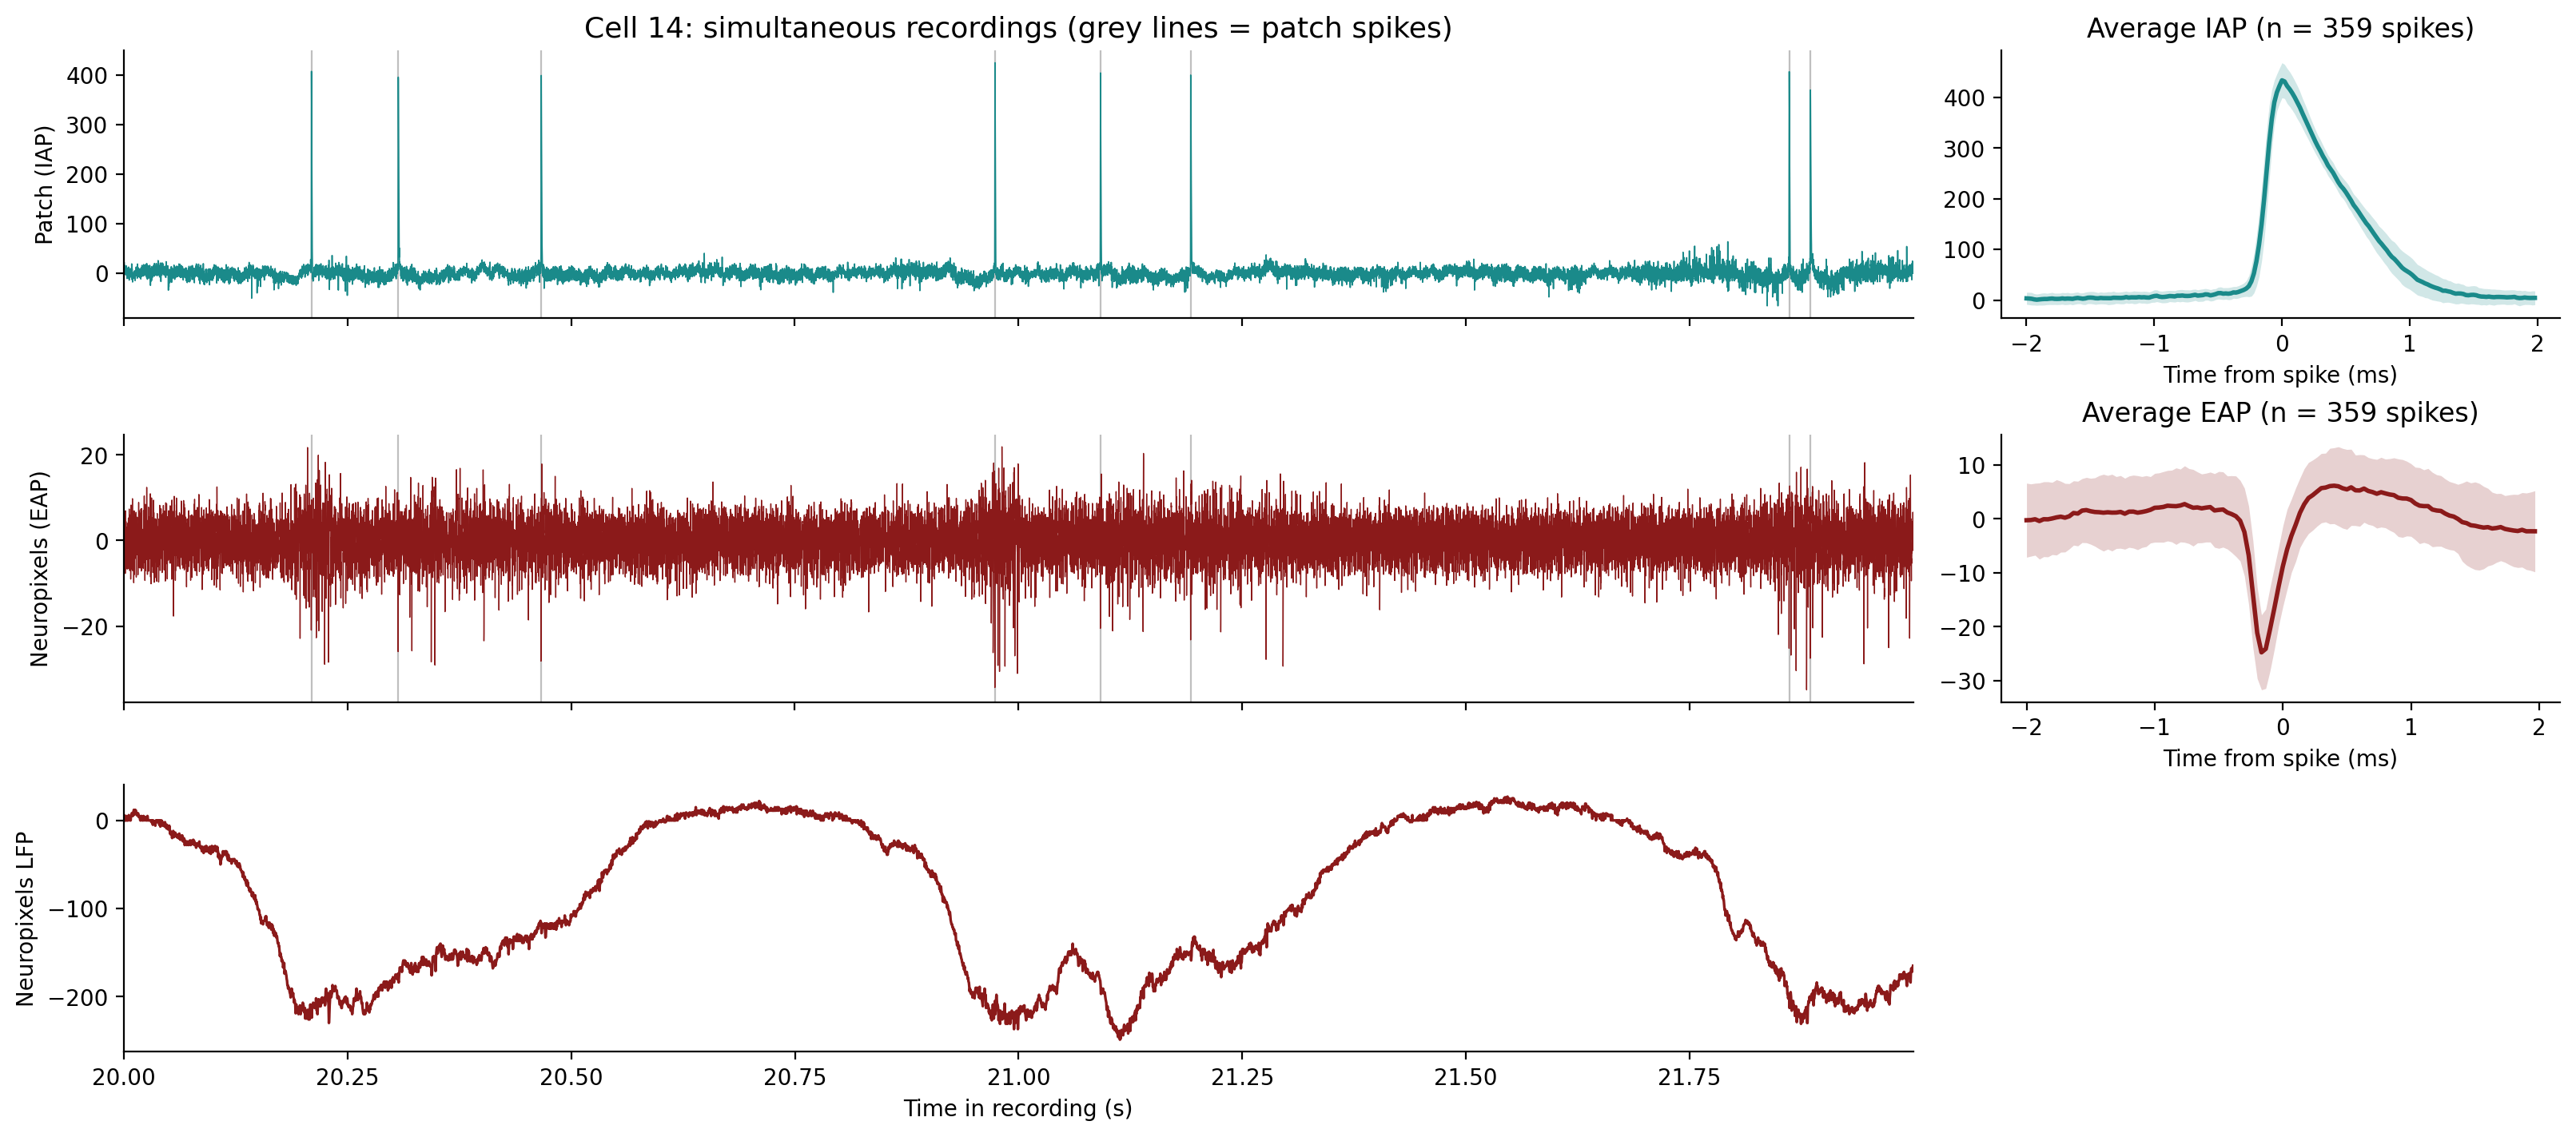

In [2]:
plot_example_recording(DATA_DIR)

## Extracting LFP features around each spike

For every patch spike we describe the surrounding LFP with a few features (Fig. 4E):
- **time domain**: the LFP mean amplitude and its variability (standard deviation);
- **spectral**: the aperiodic exponent and the power of theta (4 to 8 Hz) and gamma (30 to 55 Hz) oscillations, from multitaper spectra fit with a spectral parameterization model.

<img src="finding_notebooks_data/paper_figures/fig4_E.png" width="650">

Each feature is computed in 0.5 s windows that slide along the LFP, and then averaged over the windows centered between −55 and −5 ms (pre-spike) or between +5 and +55 ms (post-spike). Because each sliding window spans 0.5 s, the pre- and post-spike values share most of their underlying LFP. In practice they describe the LFP state in the half second around the time of the spike, rather than strictly before or after it.

## Does spike shape predict the LFP?

<img src="finding_notebooks_data/paper_figures/fig4_F.png" width="650">

For each of the 39 cells separately, we used ridge regression to predict each LFP feature from the 8 `spikewise` waveform features of each spike, scoring the prediction with 5-fold cross-validated R² and testing it against a permutation null. As a control, the same model was fit using only the log inter-spike interval, a proxy for the cell's firing rate.

Spike shape predicted the LFP amplitude and variability around the spike in most cells, far more often than firing rate alone did.

Cells with a significant prediction (of 39):
  Pre LFP Amp    waveform   87%   vs   log-ISI control   46%
  Pre LFP Std    waveform   74%   vs   log-ISI control   38%
  Post LFP Amp   waveform   90%   vs   log-ISI control   51%
  Post LFP Std   waveform   69%   vs   log-ISI control   41%


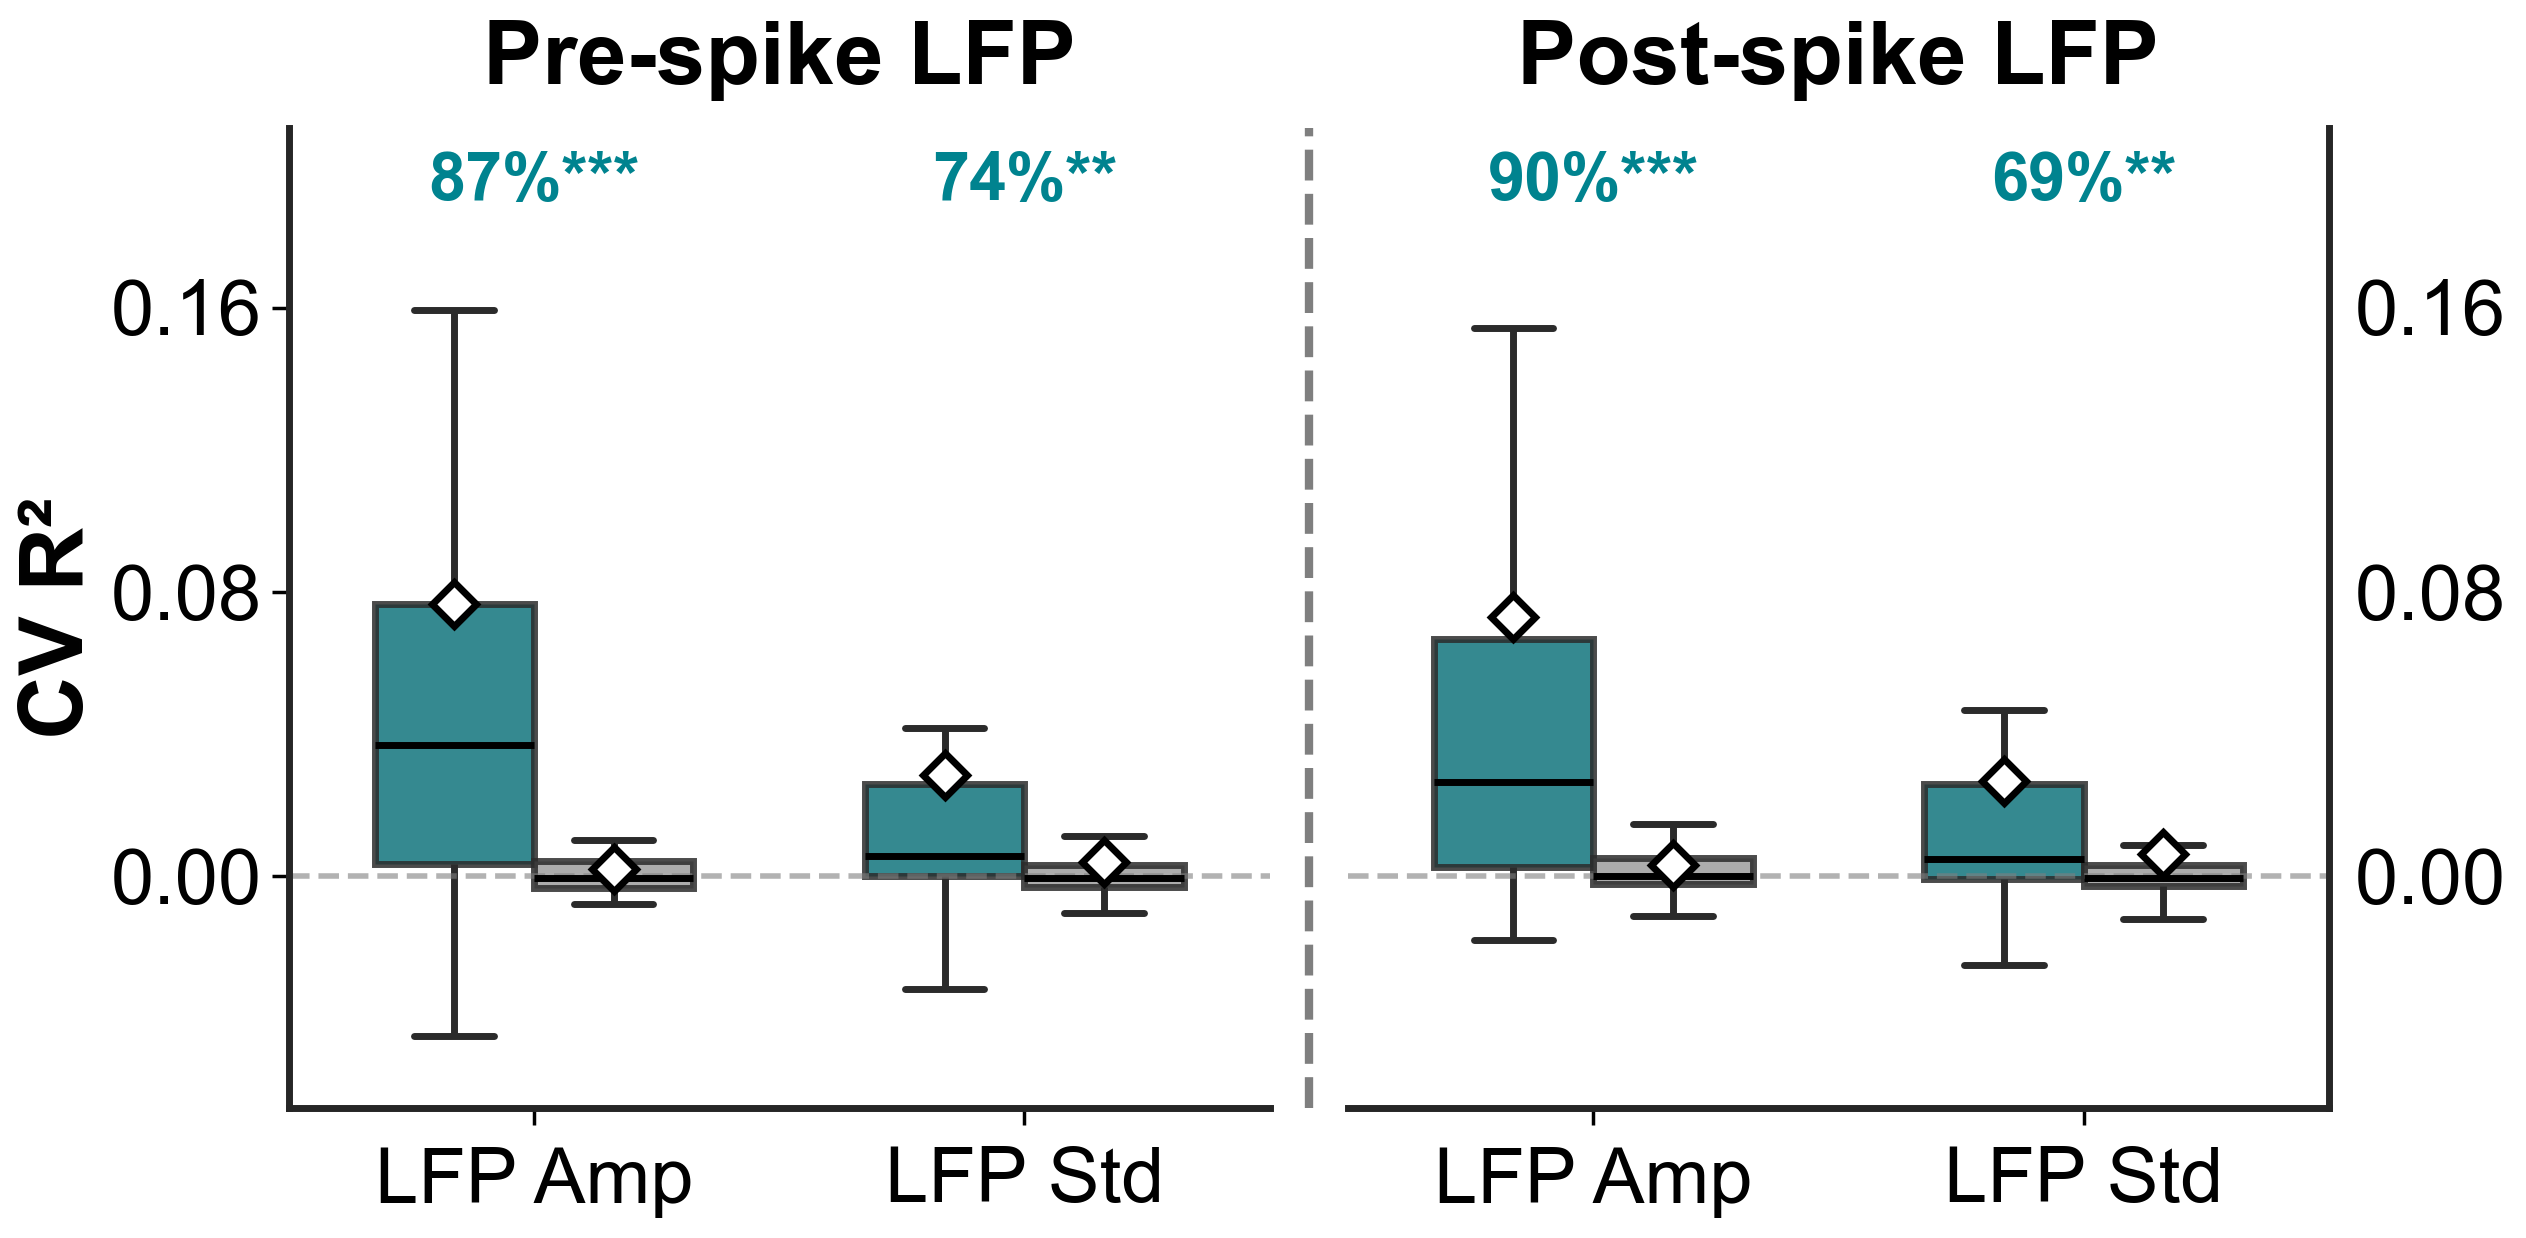

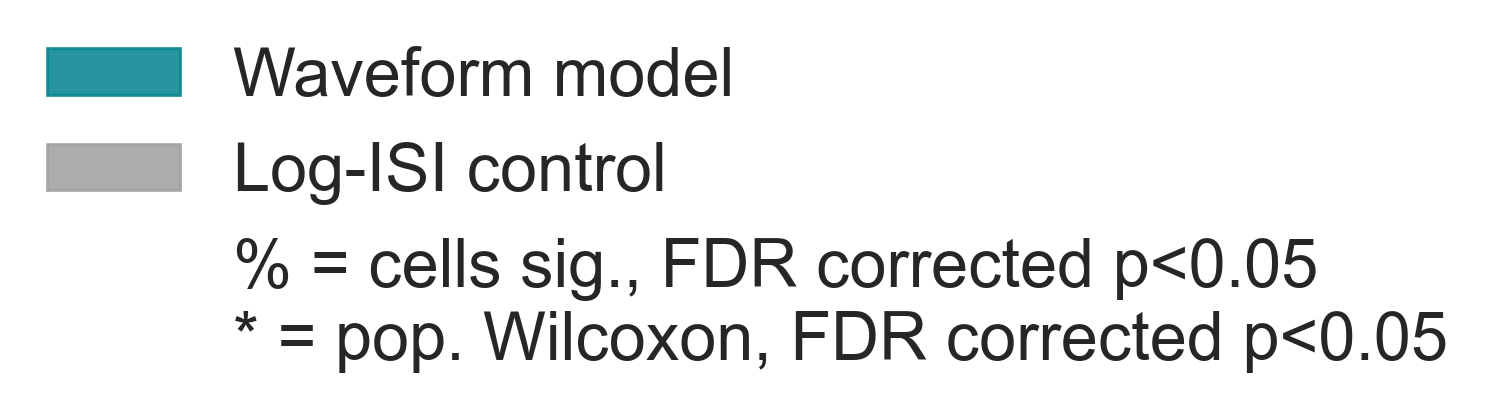

In [3]:
ridge = load_ridge_population(DATA_DIR)
df_frac, df_r2, df_tests = run_population_stats(ridge)
print_fraction_significant(ridge, df_frac)
plot_r2_boxplot(ridge, df_r2)

Effect sizes are small and vary a lot between cells: for pre-spike LFP amplitude the median cross-validated R² is 0.037 while the mean is 0.077, meaning a subset of cells shows a much stronger relationship than the rest; the strongest, cell 3, reaches R² = 0.64 (Fig. 4G, left).

The spectral features (oscillatory power and aperiodic exponent) were not predicted above zero at the population level. Only the time-domain features were:

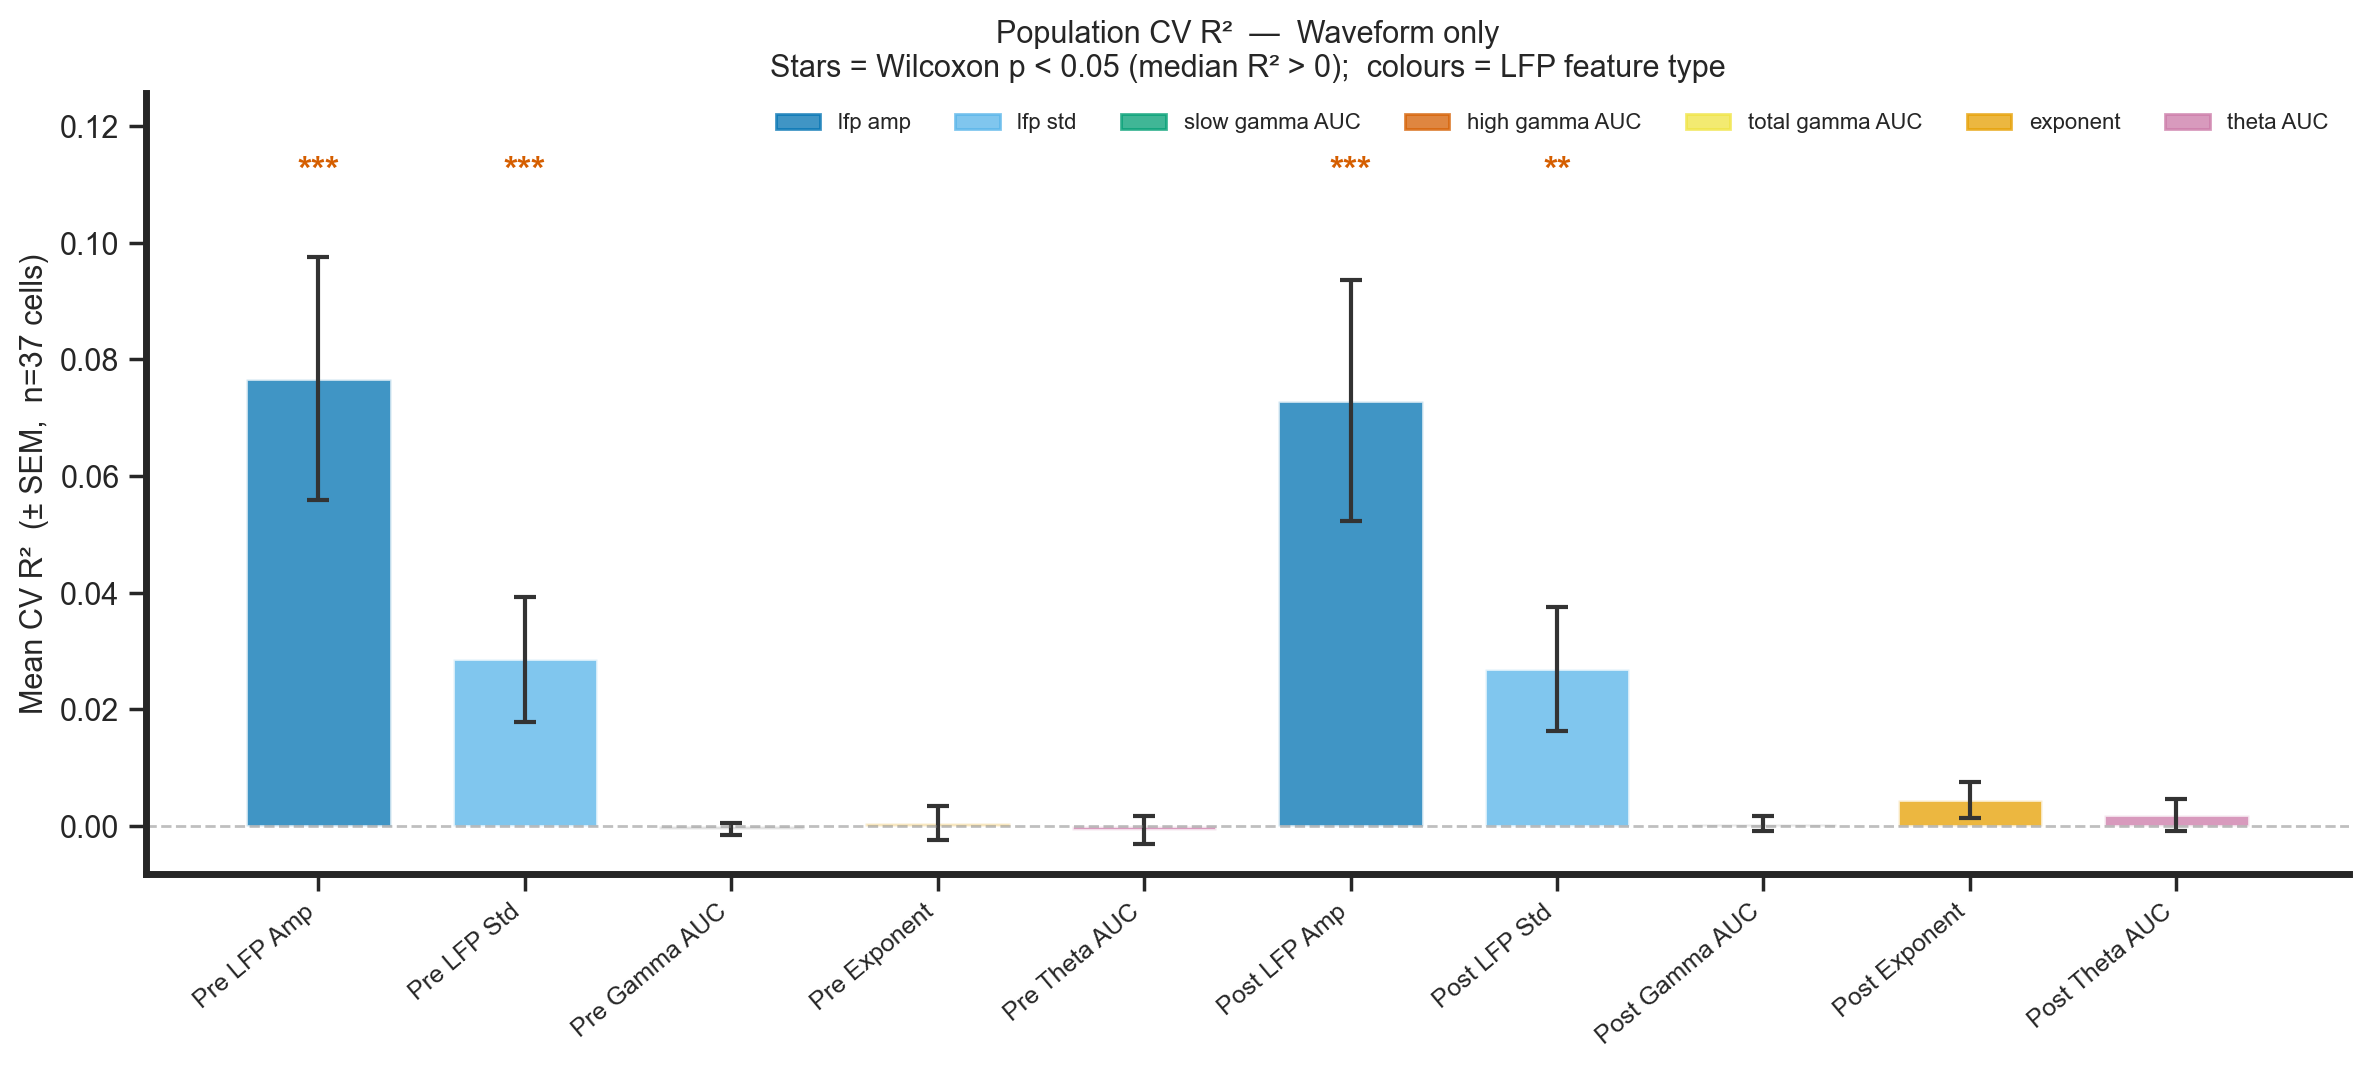

In [4]:
plot_all_lfp_features(ridge, df_r2)

Which waveform features carry this information? Looking for waveform features whose weights point the same direction across cells, three stand out for LFP amplitude: spikes with a larger inflection amplitude, a faster decay (larger λ) and a smaller ramp amplitude tend to occur when the surrounding LFP amplitude is higher (Fig. 4G, right). No waveform feature had a consistent direction across cells for LFP variability.

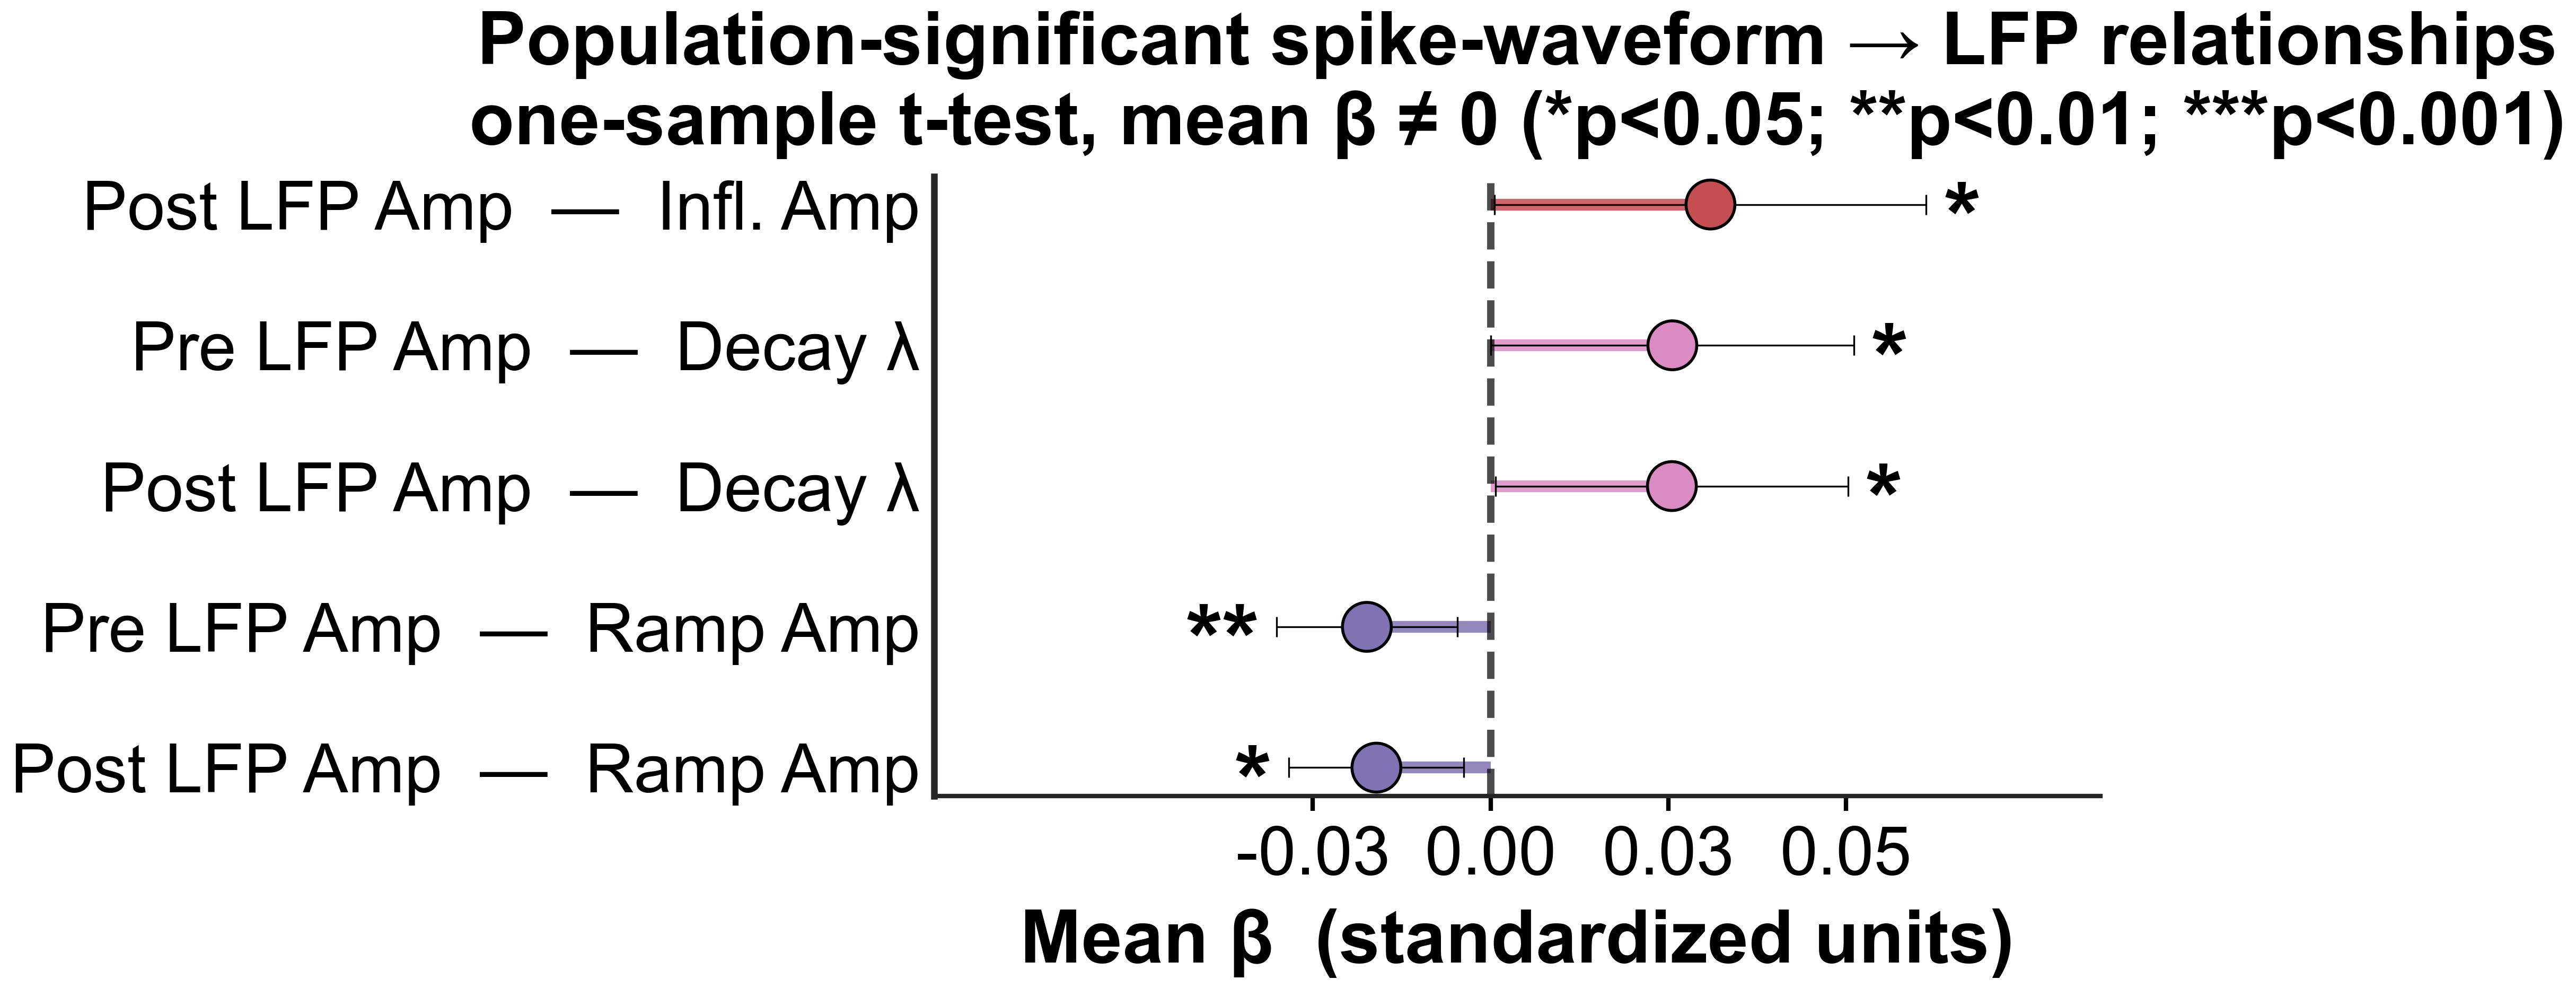

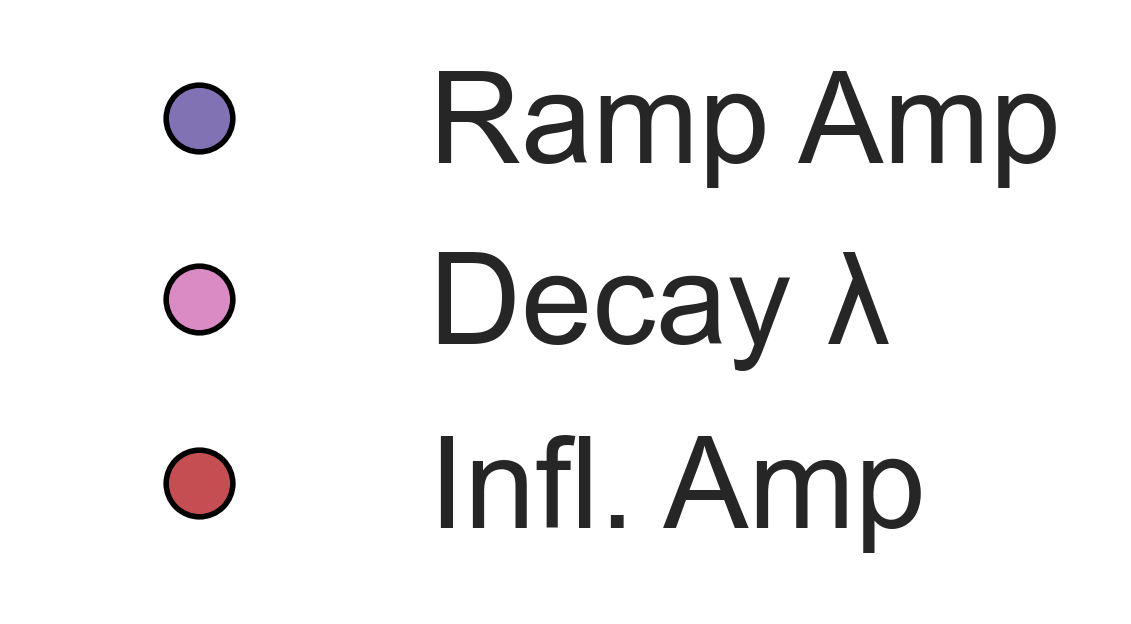

In [5]:
plot_significant_betas(ridge, df_tests)

## Explore a cell

Pick a cell to see how well its spike shape predicts each LFP feature, compared with the firing-rate (log inter-spike interval) control.

In [6]:
cell_explorer(ridge, cell='c3')

Dropdown(description='Cell:', index=2, options=(('Cell 1 (PC)', 'c1'), ('Cell 2 (PC)', 'c2'), ('Cell 3 (PC)', …

Output()